# MAST mesh generator

Builds a TokaMaker gs_Domain mesh from FAIR-MAST's level2 device geometry (pf_active, wall), following the same pattern as the OFT NSTX-U mesh generator example.

Each named coil pack (`sol`, `p4_lower`, etc) in `pf_active` stored as many individual current filaments. Merge into one bounding region with `nTurns` = filament count, matches how the reference examples treat a physical coil- https://mastapp.site/geometry_plotting.html

In [1]:
import os
import sys
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import collections
import shapely
from shapely.geometry import Point, Polygon, box
from shapely.geometry.polygon import orient
from shapely.ops import unary_union
import pandas as pd

In [2]:
# Chose this shot because it is what they use in their examples and has all features
shot_id = 30421
shot_url = f'https://s3.echo.stfc.ac.uk/mast/level2/shots/{shot_id}.zarr'

plasma_dx = 0.04
coil_dx = 0.02
vac_dx = 0.12

In [3]:
ds_pf = xr.open_zarr(shot_url, group='pf_active')
ds_wall = xr.open_zarr(shot_url, group='wall')

coilNames = sorted(set(v.rsplit('_', 1)[0] for v in ds_pf.data_vars if v.endswith('_r')))
limiter = np.column_stack([ds_wall['limiter_r'].values, ds_wall['limiter_z'].values])[:-1]  # drop repeated closing point

In [4]:
def boundingRectangle(r, z, w, h):
    # One polygon spanning every filament element in a coil pack
    rmin, rmax = (r - abs(w)/2).min(), (r + abs(w)/2).max()
    zmin, zmax = (z - h/2).min(), (z + h/2).max()
    return np.array([[rmin, zmin], [rmax, zmin], [rmax, zmax], [rmin, zmax]])

In [5]:
# Passive structure geometry and loop resistances from the MAST EFIT machine description
passiveCsv = 'MAST_info/mast_efit_passive_structure_M4.csv'
passive_dx = 0.02
# Clearance between regions of different resistivity and around the coils and limiter
gap = 0.002
snapGrid = 1e-4

def elementVertices(r0, z0, dR, dZ, ang1, ang2):
    # EFIT rectangle or parallelogram from its center, size and two shape angles in degrees
    ang1, ang2 = ang1 % 360.0, ang2 % 360.0
    tan1 = np.tan(np.radians(ang1)) if ang1 > 0 else 0.0
    tan2 = 1.0 / np.tan(np.radians(ang2)) if ang2 > 0 else 0.0
    rr = [r0 - dR/2 - dZ/2*tan2, r0 + dR/2 - dZ/2*tan2, r0 + dR/2 + dZ/2*tan2, r0 - dR/2 + dZ/2*tan2]
    zz = [z0 - dZ/2 - dR/2*tan1, z0 - dZ/2 + dR/2*tan1, z0 + dZ/2 + dR/2*tan1, z0 + dZ/2 - dR/2*tan1]
    return list(zip(rr, zz))

passive = pd.read_csv(passiveCsv)
passive['shape'] = [Polygon(elementVertices(r.R_m, r.Z_m, abs(r.DeltaR_m), abs(r.DeltaZ_m), r.ang1_deg, r.ang2_deg)) for r in passive.itertuples()]
# Loop resistance to resistivity, eta = R_loop * dR * dZ / (2 pi R_center)
passive['eta'] = passive['resist_mOhm'] * 1e-3 * passive['DeltaR_m'].abs() * passive['DeltaZ_m'].abs() / (2 * np.pi * passive['R_m'])

# Elements whose resistivities agree within 10% share a region
etaOrder = np.argsort(passive['eta'].values)
groupId = np.zeros(len(passive), dtype=int)
for k in range(1, len(etaOrder)):
    step = passive['eta'].values[etaOrder[k]] > 1.1 * passive['eta'].values[etaOrder[k - 1]]
    groupId[etaOrder[k]] = groupId[etaOrder[k - 1]] + int(step)
passive['group'] = groupId

coilPolys = {}
for name in coilNames:
    r, z, w, h = (ds_pf[f'{name}_{k}'].values for k in ('r', 'z', 'width', 'height'))
    coilPolys[name] = Polygon(boundingRectangle(r, z, w, h))

limiterPoly = Polygon(limiter)
plasmaPoly = limiterPoly.buffer(-gap)
keepOut = unary_union([limiterPoly.buffer(gap)] + [p.buffer(gap) for p in coilPolys.values()])

# One region per resistivity group
passiveRegions = {}
placed = Polygon()
for g in sorted(passive['group'].unique()):
    rows = passive[passive['group'] == g]
    shape = unary_union(list(rows['shape'])).buffer(-gap / 2).difference(keepOut).difference(placed.buffer(gap))
    shape = shapely.set_precision(shape, snapGrid)
    parts = [Polygon(p.exterior) for p in getattr(shape, 'geoms', [shape]) if p.area > 2e-5]
    placed = unary_union([placed] + parts)
    passiveRegions[f'passive{g}'] = (float(rows['eta'].median()), parts)

passive0: eta 5.92e-07, 10 elements, 5 parts
passive1: eta 7.38e-07, 24 elements, 10 parts
passive2: eta 1.30e-06, 10 elements, 7 parts
passive3: eta 3.68e-06, 4 elements, 3 parts
passive4: eta 7.17e-06, 2 elements, 2 parts
passive5: eta 1.32e-05, 26 elements, 13 parts
passive6: eta 6.95e-05, 2 elements, 2 parts


In [6]:
def ccwCoords(poly):
    return np.array(orient(poly, 1.0).exterior.coords[:-1])

def makeDomain(seeds):
    gs = gs_Domain(zpad=[1.2, 1.2], rpad=1.1)
    gs.define_region('air', vac_dx, 'boundary')
    # Vacuum sealed off by the passive structure separate region, boundary region cant take seeds
    if any(regName == 'pocketAir' for _, regName in seeds):
        gs.define_region('pocketAir', vac_dx, 'vacuum')
    gs.define_region('plasma', plasma_dx, 'plasma')
    for regName, (eta, parts) in passiveRegions.items():
        gs.define_region(regName, passive_dx, 'conductor', eta=eta)
    for name in coilNames:
        n = ds_pf[f'{name}_r'].size
        gs.define_region(name, coil_dx, 'coil', nTurns=n, coil_set=name.upper())
    gs.add_polygon(ccwCoords(plasmaPoly), 'plasma', parent_name='air')
    for regName, (eta, parts) in passiveRegions.items():
        for part in parts:
            gs.add_polygon(ccwCoords(part), regName, parent_name='air')
    for name, poly in coilPolys.items():
        gs.add_polygon(ccwCoords(poly), name, parent_name='air')
    for pt, regName in seeds:
        gs.add_enclosed(pt, regName)
    return gs

def findPockets(pts, lc, reg):
    # boundary region can't take seeds
    tri = np.asarray(lc)[:, :3]
    bad = np.where(np.asarray(reg) <= 0)[0]
    edgeCells = collections.defaultdict(list)
    for c in bad:
        t = tri[c]
        for a, b in ((t[0], t[1]), (t[1], t[2]), (t[2], t[0])):
            edgeCells[(min(a, b), max(a, b))].append(int(c))
    parent = {int(c): int(c) for c in bad}

    def root(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for cells in edgeCells.values():
        for other in cells[1:]:
            ra, rb = root(cells[0]), root(other)
            if ra != rb:
                parent[rb] = ra
    groups = collections.defaultdict(list)
    for c in bad:
        groups[root(int(c))].append(int(c))
    pockets = []
    for cells in groups.values():
        P = np.asarray(pts)[tri[cells]][:, :, :2]
        areas = np.abs((P[:, 1, 0] - P[:, 0, 0]) * (P[:, 2, 1] - P[:, 0, 1]) - (P[:, 1, 1] - P[:, 0, 1]) * (P[:, 2, 0] - P[:, 0, 0])) / 2.0
        pockets.append((float(areas.sum()), P[int(np.argmax(areas))].mean(axis=0)))
    return sorted(pockets, key=lambda p: -p[0])

# Mesh with setup_only until all pockets assigned, each seeding as found
seeds = []
for attempt in range(6):
    gs_mesh = makeDomain(seeds)
    gs_mesh.build_mesh(setup_only=True)
    pockets = findPockets(*gs_mesh.mesh.get_mesh())
    print(f'pass {attempt + 1}: {len(pockets)} unclaimed pockets, {sum(p[0] for p in pockets):.5f} m^2')
    if not pockets:
        break
    for area, pt in pockets:
        # Pocket inside passive part is member of that part, else is sealed vacuum
        owner = next((regName for regName, (eta, parts) in passiveRegions.items() if any(part.contains(Point(pt)) for part in parts)), 'pocketAir')
        seeds.append((pt, owner))

gs_mesh = makeDomain(seeds)
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
coil_dict = gs_mesh.get_coils()
cond_dict = gs_mesh.get_conductors()

Assembling regions:
  # of unique points    = 3360
  # of unique segments  = 657
Generating mesh with Triangle:
  # of points  = 15166
  # of cells   = 30191
  # of regions = 22
pass 1: 11 unclaimed pockets, 0.00347 m^2
Assembling regions:
  # of unique points    = 3360
  # of unique segments  = 657
Generating mesh with Triangle:
  # of points  = 15166
  # of cells   = 30191
  # of regions = 23
pass 2: 0 unclaimed pockets, 0.00000 m^2
Assembling regions:
  # of unique points    = 3360
  # of unique segments  = 657
Generating mesh with Triangle:
  # of points  = 15166
  # of cells   = 30191
  # of regions = 23


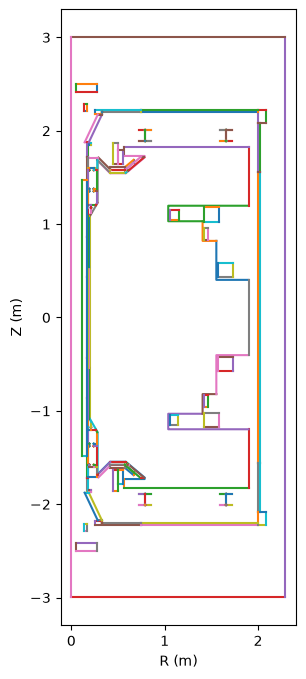

In [7]:
fig, ax = plt.subplots(figsize=(5, 8))
gs_mesh.plot_topology(fig, ax)

In [8]:
gs_mesh = makeDomain(seeds)
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
coil_dict = gs_mesh.get_coils()
cond_dict = gs_mesh.get_conductors()

Assembling regions:
  # of unique points    = 3360
  # of unique segments  = 657
Generating mesh with Triangle:
  # of points  = 15166
  # of cells   = 30191
  # of regions = 23


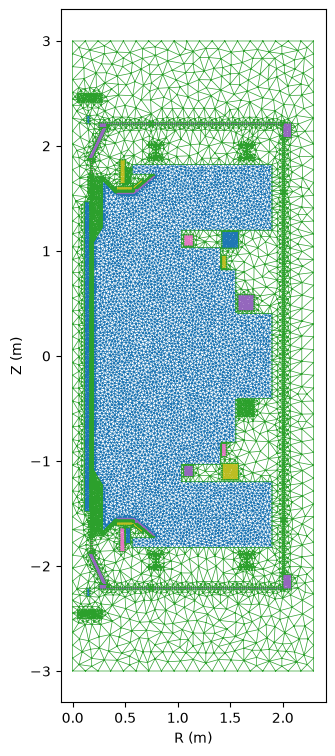

In [9]:
fig, ax = plt.subplots(figsize=(6, 9))
gs_mesh.plot_mesh(fig, ax, show_legends=False)
ax.set_aspect('equal')

In [10]:
save_gs_mesh(mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict, 'MAST_mesh.h5')